In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load Fashion-MNIST dataset
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print("Dataset shape:", X_train.shape)
print("Labels shape:", y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset shape: (60000, 28, 28)
Labels shape: (60000,)


In [3]:
# Convert pixel values from [0, 255] to [-1, 1]
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)

print("New shape:", X_train.shape)
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

New shape: (60000, 28, 28, 1)
Minimum: -1.0
Maximum: 1.0


In [4]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print("Dataset ready!")

Dataset ready!


In [13]:
def build_generator(latent_dim):

    model = tf.keras.Sequential([

        layers.Dense(
            7 * 7 * 128,
            use_bias=False,
            input_shape=(latent_dim,)
        ),

        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        # 7x7 -> 7x7
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(1, 1),
            padding='same',
            use_bias=False
        ),

        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 7x7 -> 14x14
        layers.Conv2DTranspose(
            32,
            (5, 5),
            strides=(2, 2),
            padding='same',
            use_bias=False
        ),

        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 14x14 -> 28x28
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding='same',
            use_bias=False,
            activation='tanh'
        )
    ])

    return model

In [14]:
LATENT_DIM = 100

generator = build_generator(LATENT_DIM)

generator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │           800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,472 (3.47 MB)

 Trainable params: 896,736 (3.42 MB)

 Non-trainable params: 12,736 (49.75 KB)

In [15]:
noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(
    noise,
    training=False
)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


In [16]:
decision = discriminator(generated_image)

print("Discriminator output:", decision.numpy())

Discriminator output: [[-0.00219581]]


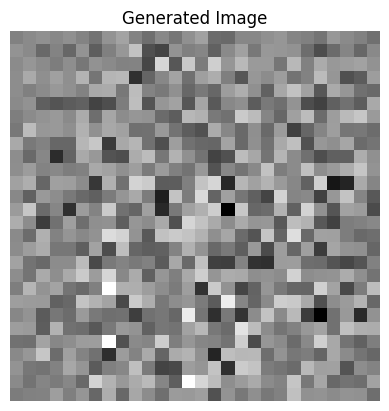

In [17]:
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.title("Generated Image")
plt.show()

In [18]:
def build_discriminator():

    model = tf.keras.Sequential([

        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding='same',
            input_shape=[28, 28, 1]
        ),

        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding='same'
        ),

        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),

        layers.Dense(1)
    ])

    return model

In [19]:
discriminator = build_discriminator()

discriminator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
decision = discriminator(generated_image)

print("Discriminator output:", decision.numpy())

Discriminator output: [[0.00288157]]


In [21]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [22]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

In [23]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [24]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [25]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update models
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [26]:
NUM_EXAMPLES = 16

seed = tf.random.normal(
    [NUM_EXAMPLES, LATENT_DIM]
)

In [27]:
def generate_and_save_images(model, epoch):

    predictions = model(
        seed,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap='gray'
        )

        plt.axis('off')

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.tight_layout()

    plt.show()

Epoch 1/20 | Generator Loss: 0.7582 | Discriminator Loss: 1.2247
Epoch 2/20 | Generator Loss: 0.7865 | Discriminator Loss: 1.3075
Epoch 3/20 | Generator Loss: 0.8386 | Discriminator Loss: 1.2544
Epoch 4/20 | Generator Loss: 0.9233 | Discriminator Loss: 1.1622
Epoch 5/20 | Generator Loss: 1.0118 | Discriminator Loss: 1.0992


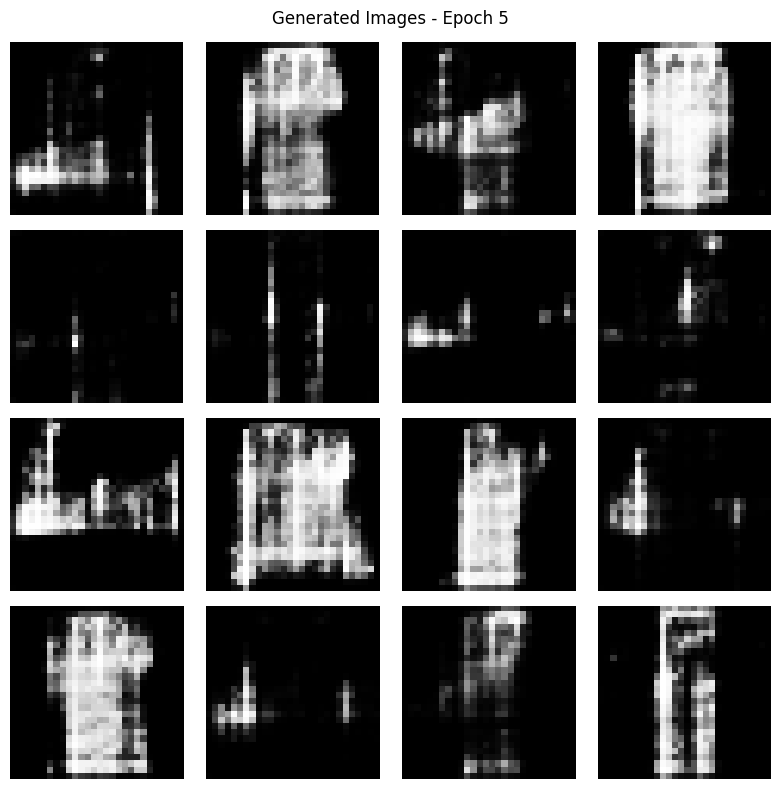

Epoch 6/20 | Generator Loss: 1.0261 | Discriminator Loss: 1.1076
Epoch 7/20 | Generator Loss: 0.9708 | Discriminator Loss: 1.1689
Epoch 8/20 | Generator Loss: 0.9485 | Discriminator Loss: 1.1848
Epoch 9/20 | Generator Loss: 0.9362 | Discriminator Loss: 1.1998
Epoch 10/20 | Generator Loss: 0.9243 | Discriminator Loss: 1.2054


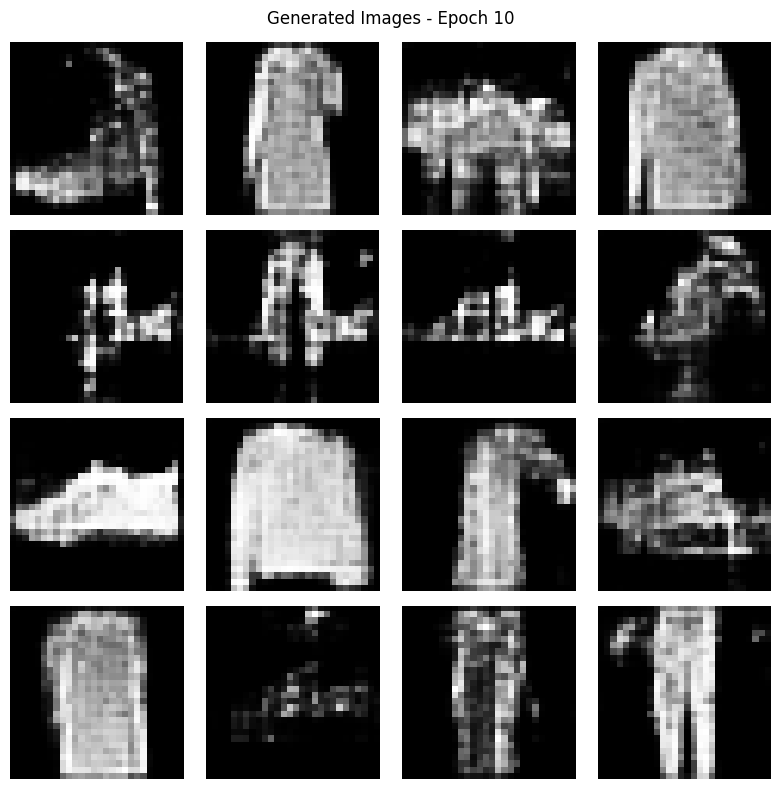

Epoch 11/20 | Generator Loss: 0.9217 | Discriminator Loss: 1.2119
Epoch 12/20 | Generator Loss: 0.9067 | Discriminator Loss: 1.2257
Epoch 13/20 | Generator Loss: 0.8784 | Discriminator Loss: 1.2449
Epoch 14/20 | Generator Loss: 0.8769 | Discriminator Loss: 1.2420
Epoch 15/20 | Generator Loss: 0.9384 | Discriminator Loss: 1.1959


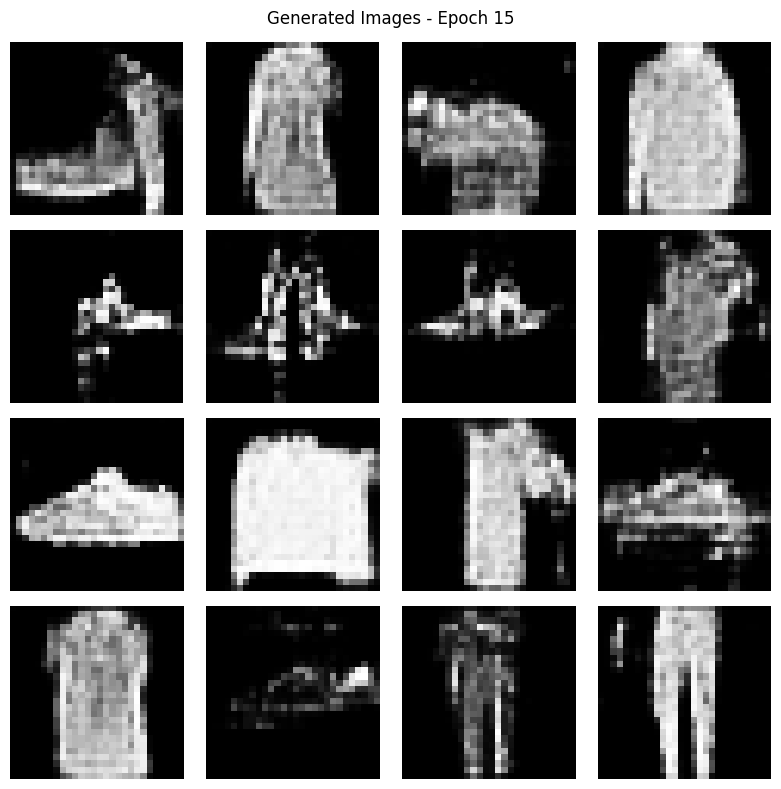

Epoch 16/20 | Generator Loss: 0.8754 | Discriminator Loss: 1.2401
Epoch 17/20 | Generator Loss: 0.8803 | Discriminator Loss: 1.2384
Epoch 18/20 | Generator Loss: 0.8627 | Discriminator Loss: 1.2505
Epoch 19/20 | Generator Loss: 0.9125 | Discriminator Loss: 1.2150
Epoch 20/20 | Generator Loss: 0.8741 | Discriminator Loss: 1.2489


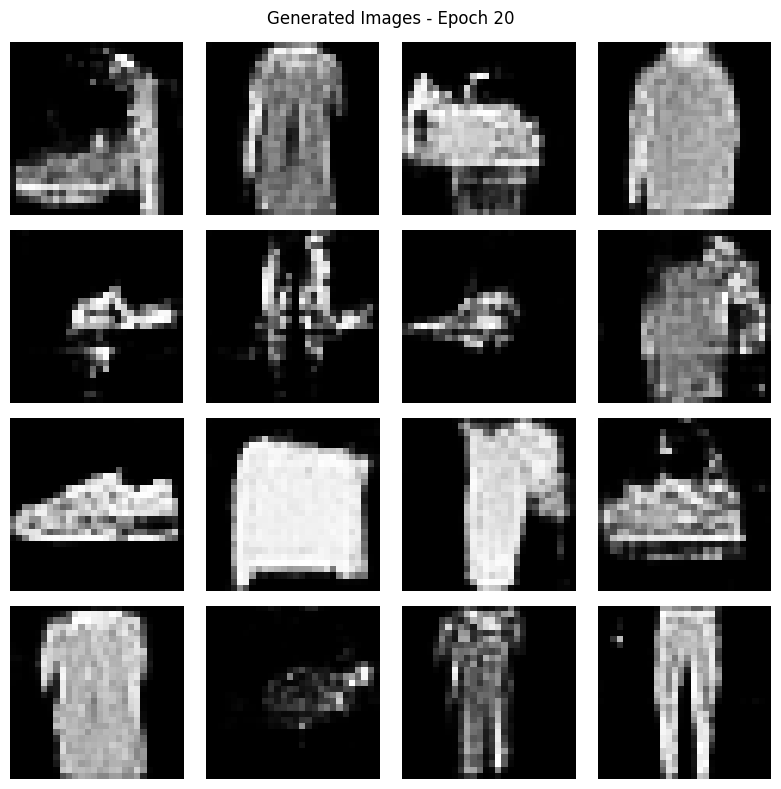

In [28]:
EPOCHS = 20

generator_losses = []
discriminator_losses = []

for epoch in range(1, EPOCHS + 1):

    gen_loss_total = 0
    disc_loss_total = 0
    batches = 0

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

        gen_loss_total += gen_loss
        disc_loss_total += disc_loss
        batches += 1

    # Average losses
    avg_gen_loss = gen_loss_total / batches
    avg_disc_loss = disc_loss_total / batches

    generator_losses.append(float(avg_gen_loss))
    discriminator_losses.append(float(avg_disc_loss))

    print(
        f"Epoch {epoch}/{EPOCHS} "
        f"| Generator Loss: {avg_gen_loss:.4f} "
        f"| Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Generate images every 5 epochs
    if epoch % 5 == 0:
        generate_and_save_images(generator, epoch)

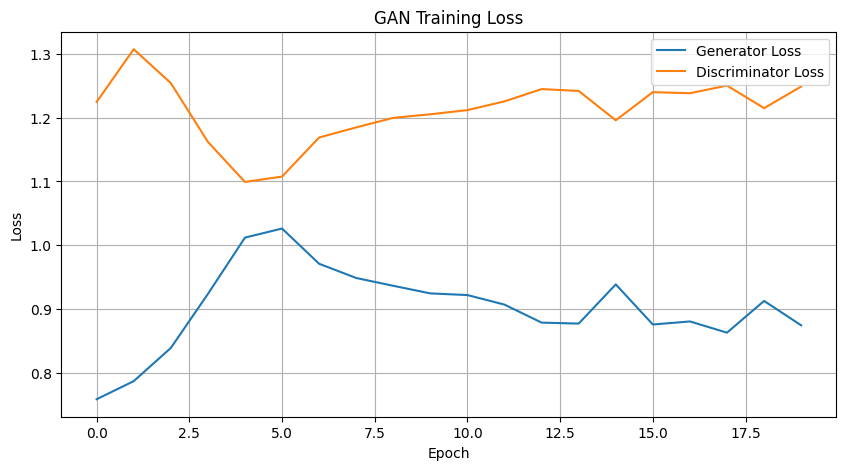

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()
plt.grid()

plt.show()

In [30]:
final_noise = tf.random.normal(
    [16, LATENT_DIM]
)

final_images = generator(
    final_noise,
    training=False
)

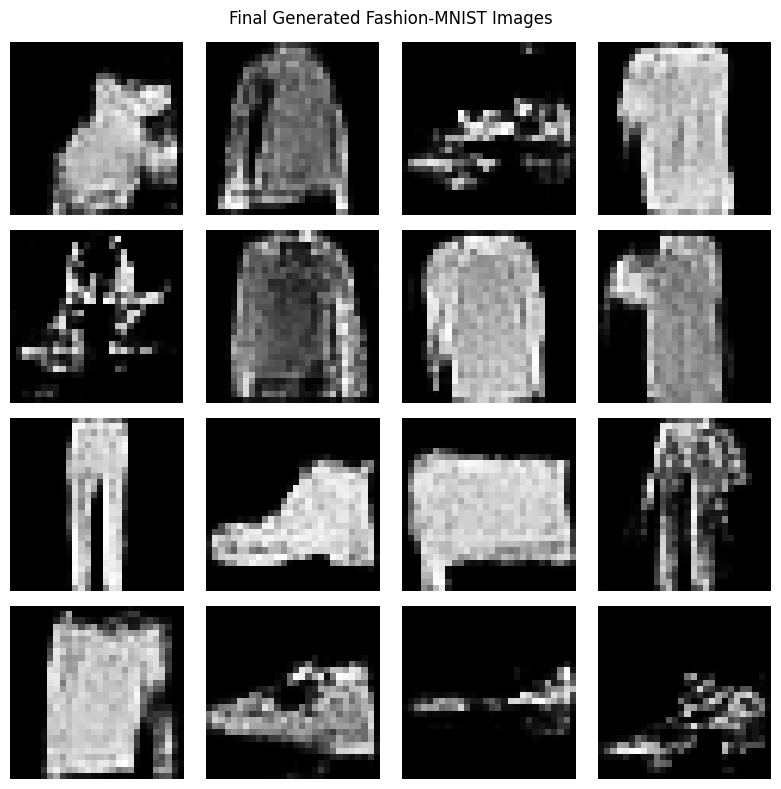

In [31]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        final_images[i, :, :, 0] * 127.5 + 127.5,
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle("Final Generated Fashion-MNIST Images")
plt.tight_layout()
plt.show()

In [32]:
generator.save("fashion_mnist_generator.keras")

print("Generator saved successfully!")

Generator saved successfully!


In [33]:
import pandas as pd

history_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Generator_Loss": generator_losses,
    "Discriminator_Loss": discriminator_losses
})

history_df.to_csv(
    "gan_training_history.csv",
    index=False
)

history_df.head()

,Epoch,Generator_Loss,Discriminator_Loss
0,1,0.758195,1.224715
1,2,0.786549,1.307486
2,3,0.838604,1.254371
3,4,0.923306,1.162160
4,5,1.011821,1.099192
